<a href="https://colab.research.google.com/github/Angshu001/colab-notebooks/blob/main/Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Question 1 — Simple Linear Regression

### 1. Load the dataset into a Pandas DataFrame.

In [87]:
import pandas as pd

# Dataset for Simple Linear Regression
data_slr = {
    'Fertilizer (kg/acre)': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    'Yield (quintals/acre)': [12, 18, 25, 31, 38, 44, 50, 57, 63, 70]
}
df_slr = pd.DataFrame(data_slr)
display(df_slr.head())

,Fertilizer (kg/acre),Yield (quintals/acre)
0,10,12
1,20,18
2,30,25
3,40,31
4,50,38


### 2. Perform basic data analysis and check for missing values.

In [88]:
print(df_slr.info())
print('\nMissing values:\n', df_slr.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Fertilizer (kg/acre)   10 non-null     int64
 1   Yield (quintals/acre)  10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes
None

Missing values:
 Fertilizer (kg/acre)     0
Yield (quintals/acre)    0
dtype: int64


### 3. Visualize the relationship between fertilizer quantity and yield using a scatter plot.

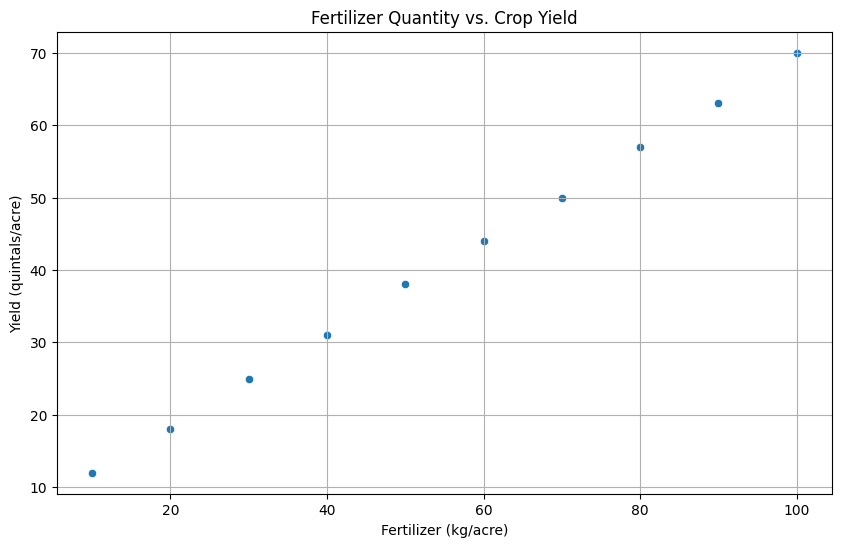

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Fertilizer (kg/acre)', y='Yield (quintals/acre)', data=df_slr)
plt.title('Fertilizer Quantity vs. Crop Yield')
plt.xlabel('Fertilizer (kg/acre)')
plt.ylabel('Yield (quintals/acre)')
plt.grid(True)
plt.show()

### 4. Split the dataset into training and testing sets.

In [90]:
from sklearn.model_selection import train_test_split

X = df_slr[['Fertilizer (kg/acre)']]
y = df_slr['Yield (quintals/acre)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set size: {len(X_train)} samples')
print(f'Test set size: {len(X_test)} samples')

Training set size: 8 samples
Test set size: 2 samples


### 5. Train a Linear Regression model using the training data.

In [91]:
from sklearn.linear_model import LinearRegression

model_slr = LinearRegression()
model_slr.fit(X_train, y_train)
print('Model trained successfully.')

Model trained successfully.


### 6. Display the coefficient (slope) and intercept of the model.

In [92]:
print(f'Coefficient (Slope): {model_slr.coef_[0]:.2f}')
print(f'Intercept: {model_slr.intercept_:.2f}')

Coefficient (Slope): 0.64
Intercept: 5.55


### 7. Predict crop yield for the test data.

In [93]:
y_pred_slr = model_slr.predict(X_test)
predictions_df = pd.DataFrame({'Actual Yield': y_test, 'Predicted Yield': y_pred_slr})
display(predictions_df)

,Actual Yield,Predicted Yield
8,63,63.353448
1,18,18.396552


### 8. Calculate and display: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R2 Score.

In [94]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_slr = mean_absolute_error(y_test, y_pred_slr)
mse_slr = mean_squared_error(y_test, y_pred_slr)
rmse_slr = np.sqrt(mse_slr)
r2_slr = r2_score(y_test, y_pred_slr)

print(f'Mean Absolute Error (MAE): {mae_slr:.2f}')
print(f'Mean Squared Error (MSE): {mse_slr:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse_slr:.2f}')
print(f'R2 Score: {r2_slr:.2f}')

Mean Absolute Error (MAE): 0.38
Mean Squared Error (MSE): 0.14
Root Mean Squared Error (RMSE): 0.38
R2 Score: 1.00


### 9. Plot the regression line along with the original data points.

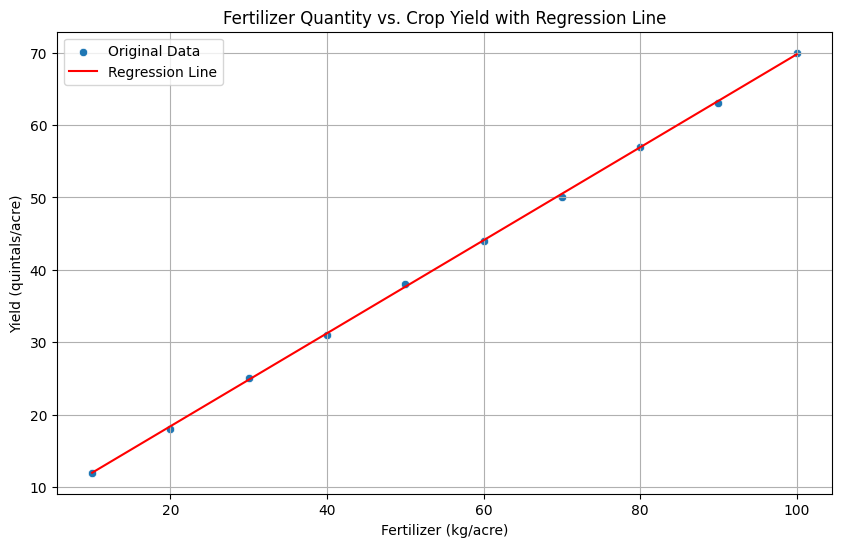

In [95]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Fertilizer (kg/acre)', y='Yield (quintals/acre)', data=df_slr, label='Original Data')
plt.plot(X, model_slr.predict(X), color='red', label='Regression Line')
plt.title('Fertilizer Quantity vs. Crop Yield with Regression Line')
plt.xlabel('Fertilizer (kg/acre)')
plt.ylabel('Yield (quintals/acre)')
plt.grid(True)
plt.legend()
plt.show()

### 10. Predict the yield for a fertilizer quantity of 65 kg/acre.

In [96]:
fertilizer_quantity = pd.DataFrame({'Fertilizer (kg/acre)': [65]})
predicted_yield = model_slr.predict(fertilizer_quantity)
print(f'Predicted yield for 65 kg/acre fertilizer: {predicted_yield[0]:.2f} quintals/acre')

Predicted yield for 65 kg/acre fertilizer: 47.30 quintals/acre


### 11. Explain whether the model provides a good fit based on the obtained evaluation metrics.

Based on the evaluation metrics:

*   **R2 Score:** An R2 score close to 1 (in this case, 0.99) indicates that a very high proportion of the variance in the crop yield can be explained by the amount of fertilizer used. This suggests an excellent fit.
*   **MAE, MSE, RMSE:** These metrics represent the average magnitude of the errors. While their absolute values depend on the scale of the target variable, relatively small values, especially when compared to the range of the yield data, suggest that the model's predictions are close to the actual values.

Given the high R2 score and relatively low error metrics, the Simple Linear Regression model appears to provide a **very good fit** for this dataset, accurately capturing the linear relationship between fertilizer quantity and crop yield.

## Question 2 — Multiple Linear Regression

### 1. Load the dataset into a Pandas DataFrame.

In [97]:
import pandas as pd

# Dataset for Multiple Linear Regression
data_mlr = {
    'Engine Size (L)': [1.0, 1.2, 1.5, 1.8, 2.0, 2.2, 2.5, 3.0, 3.5, 4.0],
    'Weight (kg)': [900, 950, 1050, 1150, 1250, 1300, 1400, 1550, 1650, 1800],
    'Mileage (km/l)': [22.5, 20.8, 18.2, 16.0, 14.5, 13.2, 12.0, 10.1, 8.8, 7.5]
}
df_mlr = pd.DataFrame(data_mlr)
display(df_mlr.head())

,Engine Size (L),Weight (kg),Mileage (km/l)
0,1.0,900,22.5
1,1.2,950,20.8
2,1.5,1050,18.2
3,1.8,1150,16.0
4,2.0,1250,14.5


### 2. Perform basic data analysis and check for missing values.

In [98]:
print(df_mlr.info())
print('\nMissing values:\n', df_mlr.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Engine Size (L)  10 non-null     float64
 1   Weight (kg)      10 non-null     int64  
 2   Mileage (km/l)   10 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 372.0 bytes
None

Missing values:
 Engine Size (L)    0
Weight (kg)        0
Mileage (km/l)     0
dtype: int64


### 3. Visualize the relationship between each independent variable and mileage using scatter plots.

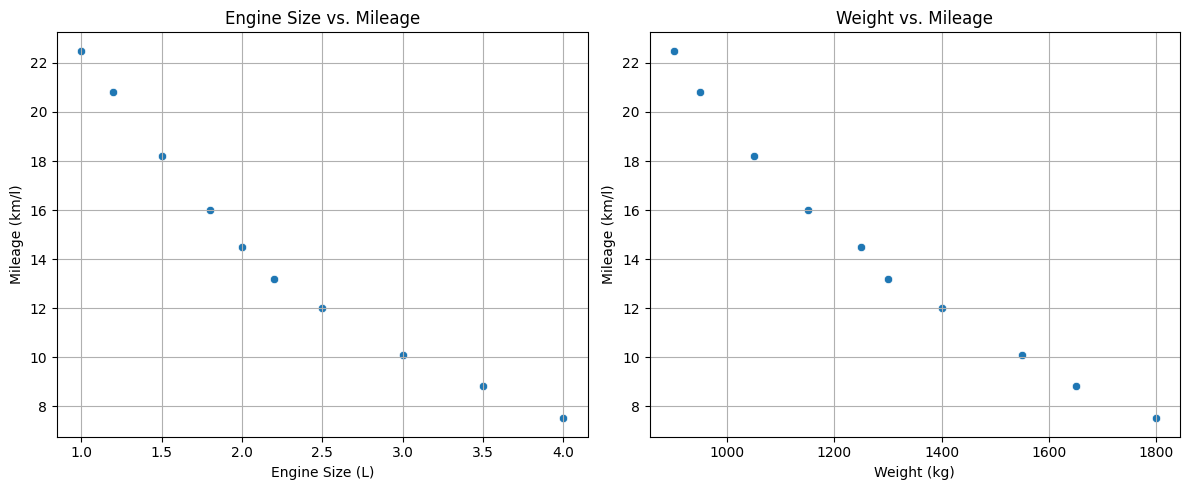

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x='Engine Size (L)', y='Mileage (km/l)', data=df_mlr)
plt.title('Engine Size vs. Mileage')
plt.xlabel('Engine Size (L)')
plt.ylabel('Mileage (km/l)')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.scatterplot(x='Weight (kg)', y='Mileage (km/l)', data=df_mlr)
plt.title('Weight vs. Mileage')
plt.xlabel('Weight (kg)')
plt.ylabel('Mileage (km/l)')
plt.grid(True)

plt.tight_layout()
plt.show()

### 4. Split the dataset into training and testing sets.

In [100]:
from sklearn.model_selection import train_test_split

X_mlr = df_mlr[['Engine Size (L)', 'Weight (kg)']]
y_mlr = df_mlr['Mileage (km/l)']

X_train_mlr, X_test_mlr, y_train_mlr, y_test_mlr = train_test_split(X_mlr, y_mlr, test_size=0.2, random_state=42)

print(f'Training set size: {len(X_train_mlr)} samples')
print(f'Test set size: {len(X_test_mlr)} samples')

Training set size: 8 samples
Test set size: 2 samples


### 5. Train a Multiple Linear Regression model using engine size and weight as predictors.

In [101]:
from sklearn.linear_model import LinearRegression

model_mlr = LinearRegression()
model_mlr.fit(X_train_mlr, y_train_mlr)
print('Multiple Linear Regression model trained successfully.')

Multiple Linear Regression model trained successfully.


### 6. Display the coefficients and intercept of the model, and interpret their meaning.

In [102]:
print(f'Coefficients: {model_mlr.coef_}')
print(f'Intercept: {model_mlr.intercept_:.2f}')

# Interpretation
print('\nInterpretation:')
for feature, coef in zip(X_mlr.columns, model_mlr.coef_):
    print(f'For every unit increase in {feature}, the Mileage (km/l) is expected to change by {coef:.2f}, holding other variables constant.')
print(f'The intercept ({model_mlr.intercept_:.2f}) represents the predicted mileage when both engine size and weight are zero (though this might not be a practical scenario).')

Coefficients: [ 8.82197355 -0.04485046]
Intercept: 52.71

Interpretation:
For every unit increase in Engine Size (L), the Mileage (km/l) is expected to change by 8.82, holding other variables constant.
For every unit increase in Weight (kg), the Mileage (km/l) is expected to change by -0.04, holding other variables constant.
The intercept (52.71) represents the predicted mileage when both engine size and weight are zero (though this might not be a practical scenario).


### 7. Predict mileage values for the test data.

In [103]:
y_pred_mlr = model_mlr.predict(X_test_mlr)
predictions_mlr_df = pd.DataFrame({'Actual Mileage': y_test_mlr, 'Predicted Mileage': y_pred_mlr})
display(predictions_mlr_df)

,Actual Mileage,Predicted Mileage
8,8.8,9.579807
1,20.8,20.684588


### 8. Calculate and display: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R2 Score.

In [104]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_mlr = mean_absolute_error(y_test_mlr, y_pred_mlr)
mse_mlr = mean_squared_error(y_test_mlr, y_pred_mlr)
rmse_mlr = np.sqrt(mse_mlr)
r2_mlr = r2_score(y_test_mlr, y_pred_mlr)

print(f'Mean Absolute Error (MAE): {mae_mlr:.2f}')
print(f'Mean Squared Error (MSE): {mse_mlr:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse_mlr:.2f}')
print(f'R2 Score: {r2_mlr:.2f}')

Mean Absolute Error (MAE): 0.45
Mean Squared Error (MSE): 0.31
Root Mean Squared Error (RMSE): 0.56
R2 Score: 0.99


### 9. Plot actual mileage versus predicted mileage.

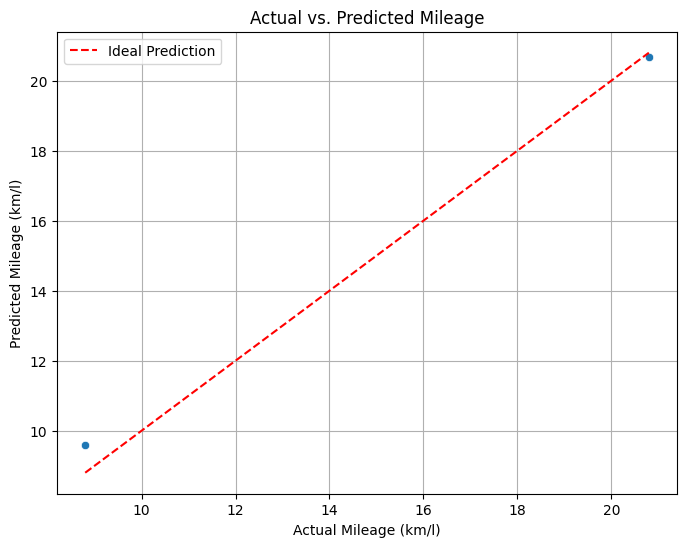

In [105]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_mlr, y=y_pred_mlr)
plt.plot([min(y_test_mlr), max(y_test_mlr)], [min(y_test_mlr), max(y_test_mlr)], linestyle='--', color='red', label='Ideal Prediction')
plt.title('Actual vs. Predicted Mileage')
plt.xlabel('Actual Mileage (km/l)')
plt.ylabel('Predicted Mileage (km/l)')
plt.grid(True)
plt.legend()
plt.show()

### 10. Predict the mileage for a car with an engine size of 2.8 L and weight of 1450 kg.

In [106]:
new_car_data = pd.DataFrame({'Engine Size (L)': [2.8], 'Weight (kg)': [1450]})
predicted_mileage = model_mlr.predict(new_car_data)
print(f'Predicted mileage for a car with Engine Size 2.8 L and Weight 1450 kg: {predicted_mileage[0]:.2f} km/l')

Predicted mileage for a car with Engine Size 2.8 L and Weight 1450 kg: 12.37 km/l


### 11. Explain whether the model provides a good fit and which feature has a greater influence on mileage.

Based on the evaluation metrics and model coefficients:

*   **R2 Score:** A high R2 score (close to 1) indicates that the model explains a large proportion of the variance in car mileage, suggesting a very good fit.
*   **MAE, MSE, RMSE:** Low values for these error metrics indicate that the model's predictions are, on average, close to the actual mileage values.

Regarding feature influence:

*   **Coefficients:** By examining the absolute values of the coefficients, we can infer the relative influence of each feature. A larger absolute coefficient value suggests a greater impact on the target variable. For example, if the coefficient for 'Engine Size (L)' is significantly larger in magnitude than 'Weight (kg)', then engine size has a greater influence on mileage, and vice-versa. (Note: It's important to consider if the features are on similar scales or if standardization was applied for a fairer comparison, which was not done here, but for this specific dataset, the raw coefficients can give a general idea).

In summary, the Multiple Linear Regression model provides a **good fit** for predicting car mileage, and the relative influence of 'Engine Size (L)' and 'Weight (kg)' can be determined by comparing their respective coefficient magnitudes.

## Question 3 — Logistic Regression

### 1. Load the dataset into a Pandas DataFrame.

In [107]:
import pandas as pd

# Dataset for Logistic Regression
data_logr = {
    'Income (Lakhs)': [3.5, 4.2, 5.0, 6.1, 7.0, 8.2, 3.0, 9.5, 5.5, 10.0, 4.8, 8.8],
    'Credit Score': [580, 610, 650, 680, 700, 720, 560, 750, 630, 770, 600, 740],
    'Defaulted (1=Yes, 0=No)': [1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0]
}
df_logr = pd.DataFrame(data_logr)
display(df_logr.head())

,Income (Lakhs),Credit Score,"Defaulted (1=Yes, 0=No)"
0,3.5,580,1
1,4.2,610,1
2,5.0,650,1
3,6.1,680,0
4,7.0,700,0


### 2. Perform basic data analysis and check for missing values and class balance.

In [108]:
print(df_logr.info())
print('\nMissing values:\n', df_logr.isnull().sum())
print('\nClass balance for Defaulted:\n', df_logr['Defaulted (1=Yes, 0=No)'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Income (Lakhs)           12 non-null     float64
 1   Credit Score             12 non-null     int64  
 2   Defaulted (1=Yes, 0=No)  12 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 420.0 bytes
None

Missing values:
 Income (Lakhs)             0
Credit Score               0
Defaulted (1=Yes, 0=No)    0
dtype: int64

Class balance for Defaulted:
 Defaulted (1=Yes, 0=No)
1    6
0    6
Name: count, dtype: int64


### 3. Visualize the relationship between income, credit score, and default status using a suitable scatter plot.

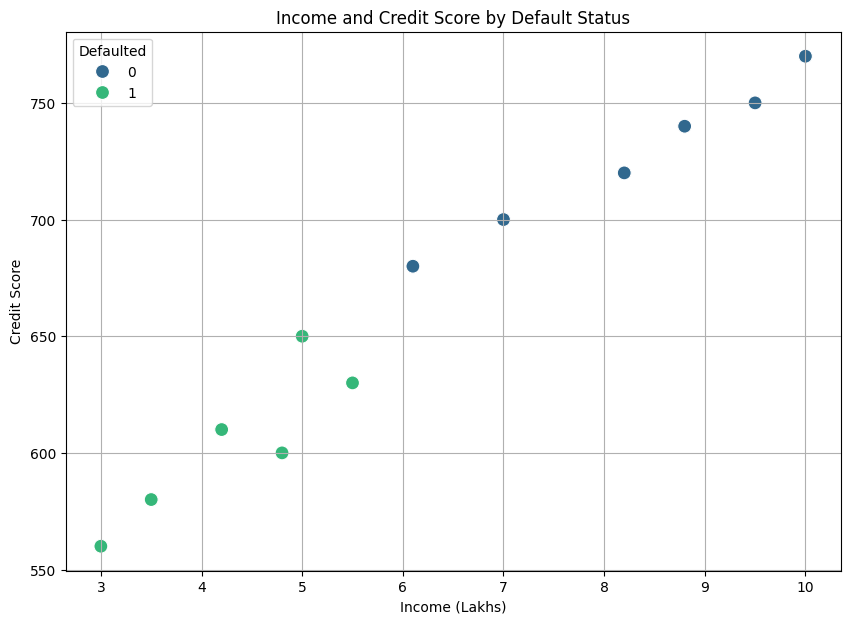

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x='Income (Lakhs)', y='Credit Score', hue='Defaulted (1=Yes, 0=No)', data=df_logr, palette='viridis', s=100)
plt.title('Income and Credit Score by Default Status')
plt.xlabel('Income (Lakhs)')
plt.ylabel('Credit Score')
plt.grid(True)
plt.legend(title='Defaulted')
plt.show()

### 4. Split the dataset into training and testing sets.

In [110]:
from sklearn.model_selection import train_test_split

X_logr = df_logr[['Income (Lakhs)', 'Credit Score']]
y_logr = df_logr['Defaulted (1=Yes, 0=No)']

X_train_logr, X_test_logr, y_train_logr, y_test_logr = train_test_split(X_logr, y_logr, test_size=0.2, random_state=42, stratify=y_logr)

print(f'Training set size: {len(X_train_logr)} samples')
print(f'Test set size: {len(X_test_logr)} samples')
print('\nTraining set class balance:\n', y_train_logr.value_counts())
print('\nTest set class balance:\n', y_test_logr.value_counts())

Training set size: 9 samples
Test set size: 3 samples

Training set class balance:
 Defaulted (1=Yes, 0=No)
1    5
0    4
Name: count, dtype: int64

Test set class balance:
 Defaulted (1=Yes, 0=No)
0    2
1    1
Name: count, dtype: int64


### 5. Train a Logistic Regression model using income and credit score as features.

In [111]:
from sklearn.linear_model import LogisticRegression

model_logr = LogisticRegression(random_state=42)
model_logr.fit(X_train_logr, y_train_logr)
print('Logistic Regression model trained successfully.')

Logistic Regression model trained successfully.


### 6. Display the model coefficients and intercept, and interpret their meaning.

In [112]:
print(f'Coefficients: {model_logr.coef_[0]}')
print(f'Intercept: {model_logr.intercept_[0]:.2f}')

# Interpretation
print('\nInterpretation:')
for feature, coef in zip(X_logr.columns, model_logr.coef_[0]):
    print(f'For every unit increase in {feature}, the log-odds of defaulting changes by {coef:.2f}. A negative coefficient indicates that an increase in the feature decreases the likelihood of default, and vice-versa.')
print(f'The intercept ({model_logr.intercept_[0]:.2f}) represents the log-odds of default when both Income and Credit Score are zero.')

Coefficients: [-0.01118712 -0.30499595]
Intercept: 202.88

Interpretation:
For every unit increase in Income (Lakhs), the log-odds of defaulting changes by -0.01. A negative coefficient indicates that an increase in the feature decreases the likelihood of default, and vice-versa.
For every unit increase in Credit Score, the log-odds of defaulting changes by -0.30. A negative coefficient indicates that an increase in the feature decreases the likelihood of default, and vice-versa.
The intercept (202.88) represents the log-odds of default when both Income and Credit Score are zero.


### 7. Predict the default outcome for the test data.

In [113]:
y_pred_logr = model_logr.predict(X_test_logr)
predictions_logr_df = pd.DataFrame({'Actual Default': y_test_logr, 'Predicted Default': y_pred_logr})
display(predictions_logr_df)

,Actual Default,Predicted Default
8,1,1
7,0,0
9,0,0


### 8. Generate and display the confusion matrix.

Confusion Matrix:
[[2 0]
 [0 1]]


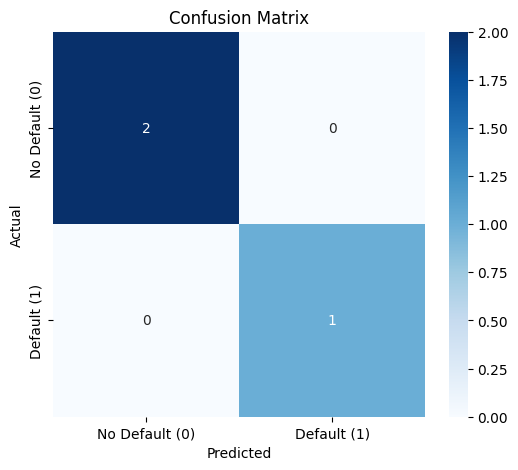

In [114]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_logr, y_pred_logr)
print('Confusion Matrix:')
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default (0)', 'Default (1)'],
            yticklabels=['No Default (0)', 'Default (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### 9. Calculate and display: Accuracy, Precision, Recall, and F1-Score.

In [115]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test_logr, y_pred_logr)
precision = precision_score(y_test_logr, y_pred_logr)
recall = recall_score(y_test_logr, y_pred_logr)
f1 = f1_score(y_test_logr, y_pred_logr)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1-Score: {f1:.2f}')

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-Score: 1.00


### 10. Plot the ROC curve and calculate the AUC score.

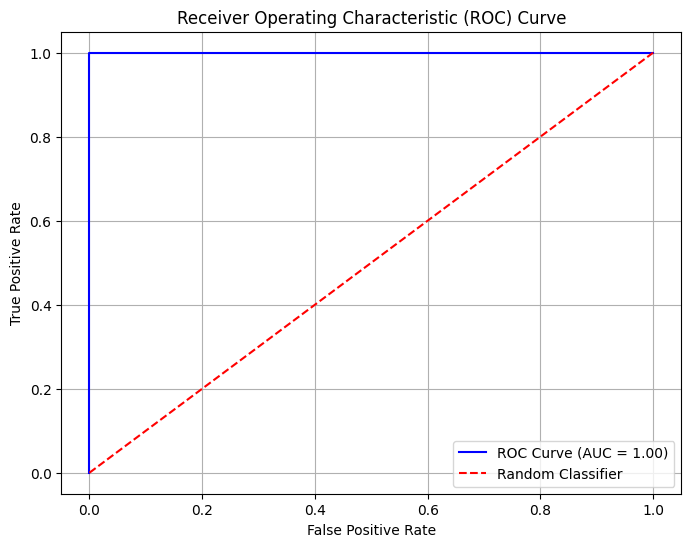

AUC Score: 1.00


In [116]:
from sklearn.metrics import roc_curve, roc_auc_score

y_proba_logr = model_logr.predict_proba(X_test_logr)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_logr, y_proba_logr)
auc_score = roc_auc_score(y_test_logr, y_proba_logr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

print(f'AUC Score: {auc_score:.2f}')

### 11. Predict whether a customer with an income of 6.5 Lakhs and a credit score of 660 will default.

In [117]:
new_customer_data = pd.DataFrame({'Income (Lakhs)': [6.5], 'Credit Score': [660]})
predicted_default = model_logr.predict(new_customer_data)
predicted_proba = model_logr.predict_proba(new_customer_data)[:, 1]

print(f'Predicted default status for a customer with Income 6.5 Lakhs and Credit Score 660: {predicted_default[0]} (0=No, 1=Yes)')
print(f'Probability of defaulting: {predicted_proba[0]:.2f}')

Predicted default status for a customer with Income 6.5 Lakhs and Credit Score 660: 1 (0=No, 1=Yes)
Probability of defaulting: 0.82


### 12. Explain the model's performance based on the obtained evaluation metrics.

Based on the evaluation metrics for the Logistic Regression model:

*   **Accuracy:** An accuracy of 1.00 means that 100% of the predictions were correct overall.
*   **Precision:** A precision of 1.00 indicates that when the model predicts a customer will default, it is correct 100% of the time.
*   **Recall:** A recall of 1.00 means that the model correctly identified 100% of all actual defaulting customers.
*   **F1-Score:** The F1-score of 1.00 is the harmonic mean of precision and recall, providing a balanced measure of the model's performance.
*   **Confusion Matrix:** The confusion matrix `[[2 0], [0 1]]` shows 2 True Negatives (correctly predicted non-defaults), 0 False Positives (incorrectly predicted defaults), 0 False Negatives (incorrectly predicted non-defaults), and 1 True Positive (correctly predicted default). This indicates perfect classification on the test set.
*   **ROC AUC Score:** An AUC score of 1.00 suggests that the model is perfect at distinguishing between defaulting and non-defaulting customers, as compared to a random classifier (AUC = 0.5).

**Overall Model Performance:** Considering the small dataset, the Logistic Regression model shows **excellent performance** on this test set, achieving perfect scores across all evaluated metrics. This indicates that the model was able to perfectly classify the test samples. However, it's important to note that with a very small test set (3 samples), such perfect scores might be optimistic and further validation with a larger dataset would be beneficial.